# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Types of Data in Coastal Engineering

- **Time series (waves, tides)**
- Spatial data (bathymetry, shoreline)
- Spatio-temporal data (wave fields, currents)

## Time Series

A time series is a sequence of observations indexed in time.

Example:
Hs(t) = wave height at time t

Key properties:
- temporal dependence
- seasonality
- trends

**CARGAMOS LOS DATOS**

['Fecha', 'Hs', 'Altura signif. de cruce por cero (H1/3)(m)', 'Periodo Medio(s)', 'Periodo Medio Tm02(s)', 'Periodo de Pico(s)', 'Altura Máxima del Oleaje(m)', 'Periodo de la Ola Maxima(s)', 'Canal de obtencion de los datos', 'Direcc. Media de Proced.(0=N,90=E)', 'Direccion Media en el Pico Espectral(0=N,90=E)', 'Dispersión angular en toda la banda resuelta(grados)', 'Dispersión angular en el pico de energía espectral(grados)', 'Canal de obtencion de los datos.1']


C:\Users\user\AppData\Local\Temp\ipykernel_25536\2874400534.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")


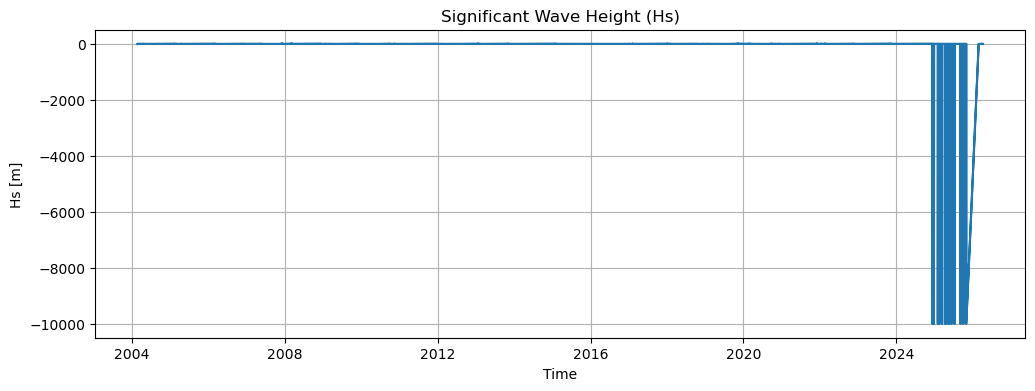

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")

# Preview
df.head()
print(df.columns.tolist())
# Convert date
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs"] = pd.to_numeric(df["Hs"], errors="coerce")
# Set index
df.set_index("Fecha", inplace=True)
plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Data Quality Issues

When working with real coastal datasets, data quality problems are very common.

In this dataset, we observe:

- Presence of extreme values such as **-9999**
- These values do not represent physical measurements
- They are used as **missing data flags (NaN equivalents)**

### Why is this a problem?

- These values distort visualization
- They can completely break machine learning models
- They must be removed or properly handled before analysis

### Cleaning step

We replace invalid values (-9999) with NaN and remove them from the analysis.

After cleaning:
- The time series becomes physically meaningful
- However, **temporal gaps appear in the data**

These gaps are exactly the type of problem we aim to solve using Deep Learning methods such as LSTM.

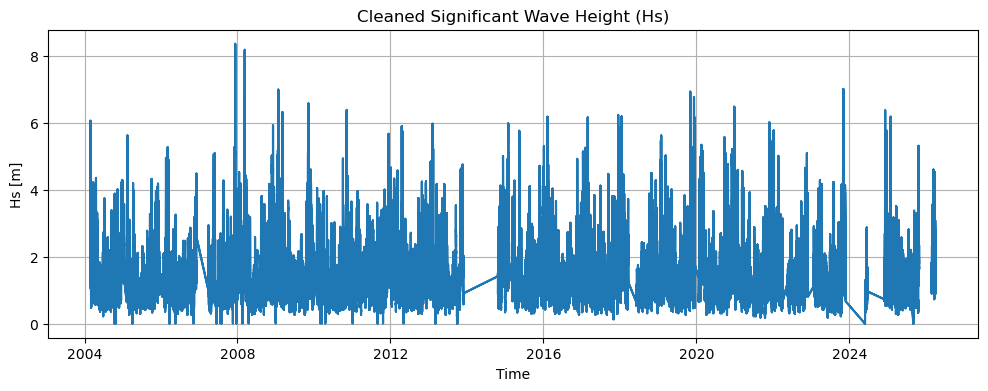

In [2]:
# Replace invalid values (-9999) with NaN
df["Hs"] = df["Hs"].replace(-9999.9, np.nan)

# Remove NaNs
df["Hs_clean"] = df["Hs"].replace(-9999.9, np.nan)

plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Cleaned Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Exploratory Data Analysis (EDA)

Before applying any machine learning model, it is essential to understand the data.

In this section, we will:
- analyze the distribution of the variables
- explore temporal patterns
- identify anomalies and gaps
- understand the structure of the dataset

This step is critical in any real data science workflow.

In [3]:
df["Hs_clean"].describe()


count    309708.000000
mean          1.419349
std           0.832626
min           0.000000
25%           0.830000
50%           1.200000
75%           1.780000
max           8.370000
Name: Hs_clean, dtype: float64

What values do we have?

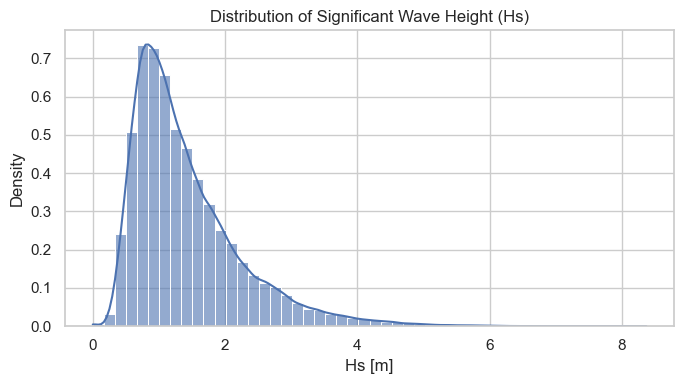

In [4]:
import seaborn as sns
# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

sns.histplot(
    df["Hs_clean"].dropna(),
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

plt.title("Distribution of Significant Wave Height (Hs)", fontsize=12)
plt.xlabel("Hs [m]")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## Temporal Analysis

The distribution of wave height is useful, but it does not show how the system evolves in time.

In coastal engineering, temporal structure is essential:
- storms appear as peaks
- calm periods alternate with energetic conditions
- missing data may occur in blocks rather than randomly

For this reason, we now inspect the time series in detail.

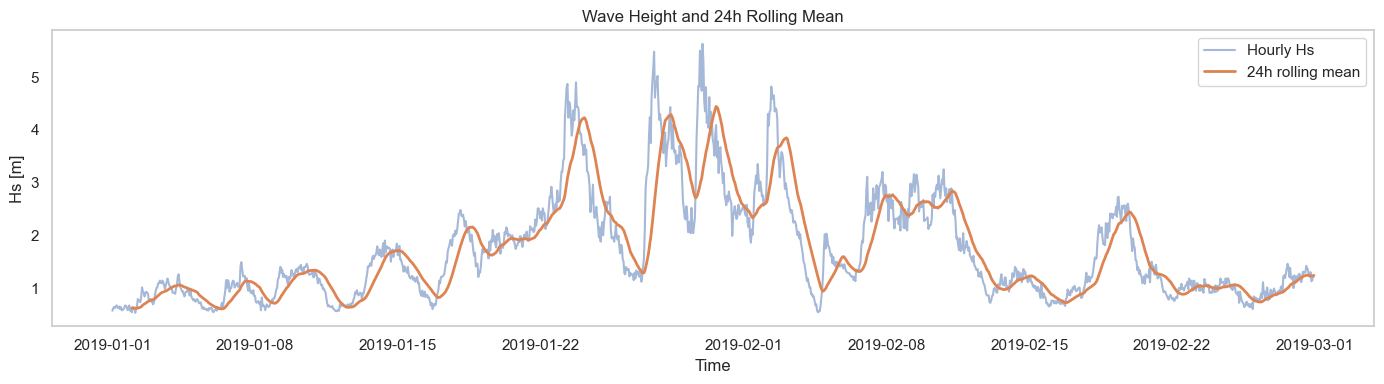

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";", low_memory=False)

# Clean likely junk
df.columns = df.columns.str.strip()
df["Fecha"] = df["Fecha"].astype(str).str.strip()
df["Hs"] = df["Hs"].astype(str).str.strip()

df = df[
    (df["Fecha"] != "Fecha") &
    (df["Fecha"] != "=======") &
    (df["Hs"] != "Hs")
].copy()

# Parse types
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H", errors="coerce")
df["Hs_clean"] = pd.to_numeric(df["Hs"], errors="coerce")

# Drop invalid rows
df = df.dropna(subset=["Fecha", "Hs_clean"]).copy()

# Set index and sort
df = df.set_index("Fecha").sort_index()

# Optional: remove duplicate timestamps
df = df[~df.index.duplicated(keep="first")]

# Zoom
df_zoom = df.loc["2019-01":"2019-02", ["Hs_clean"]].copy()
df_zoom["Hs_rolling"] = df_zoom["Hs_clean"].rolling(window=24).mean()

# Plot
plt.figure(figsize=(14, 4))
plt.plot(df_zoom.index, df_zoom["Hs_clean"], label="Hourly Hs", alpha=0.5)
plt.plot(df_zoom.index, df_zoom["Hs_rolling"], label="24h rolling mean", linewidth=2)

plt.title("Wave Height and 24h Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
n_total = df["Hs_clean"].shape[0]
n_missing = df["Hs_clean"].isna().sum()
missing_pct = 100 * n_missing / n_total

print(f"Total samples: {n_total}")
print(f"Missing samples: {n_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Total samples: 154875
Missing samples: 0
Missing percentage: 0.00%


Not all gaps are the same. Some are short and others are very long. This greatly influences the difficulty of the problem.

## Problem Formulation

From the exploratory analysis, we observe that:

- the wave record has a clear temporal structure
- missing values are present and may occur in contiguous blocks
- the reconstruction problem is therefore not trivial

A suitable model should:
- exploit temporal dependence
- learn from previous observations
- reconstruct missing values in a physically consistent way

This motivates the use of recurrent neural networks, and in particular, LSTM models.

## Preparing Data for Reconstruction


From the previous analysis, we observed that the dataset contains missing values and irregularities.

To build a controlled experiment, we select a short time window with:
- minimal missing data
- clear temporal dynamics

This allows us to:
- better visualize the signal
- create artificial gaps
- evaluate reconstruction methods

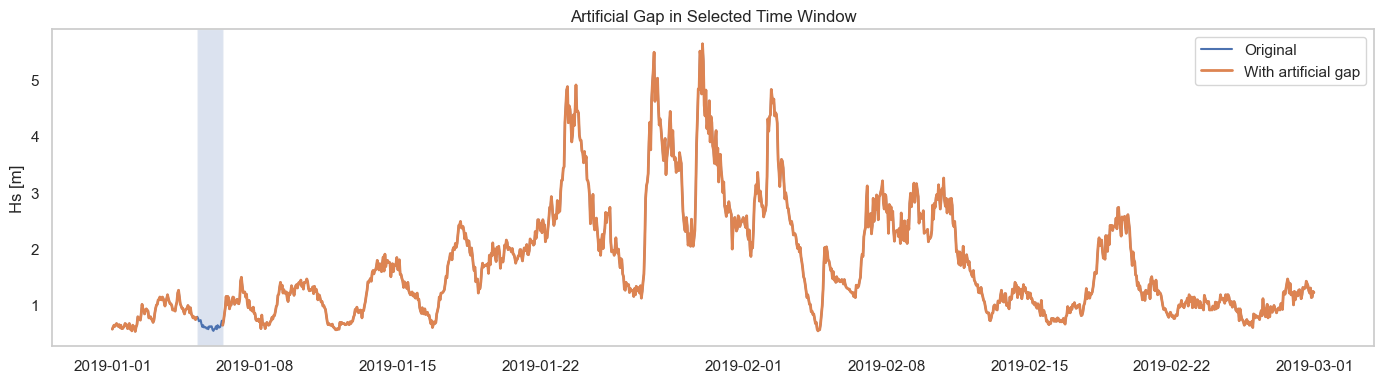

In [7]:
series = df_zoom["Hs_clean"].copy()

gap_start = 100
gap_len = 30

series_gap = series.copy()
series_gap.iloc[gap_start:gap_start+gap_len] = np.nan
plt.figure(figsize=(14,4))

plt.plot(series, label="Original")
plt.plot(series_gap, label="With artificial gap", linewidth=2)

plt.axvspan(series.index[gap_start],
            series.index[gap_start+gap_len],
            alpha=0.2)

plt.legend()
plt.title("Artificial Gap in Selected Time Window")
plt.ylabel("Hs [m]")
plt.grid()

plt.tight_layout()
plt.show()

In [8]:
print("Length:", len(series))

Length: 1409


> Given a signal with a missing segment, estimate the missing values using temporal information from the surrounding data.

### Why is this challenging?
This is not a simple interpolation task because:
- the signal is nonlinear
- there may be energetic events and rapid changes
- temporal dependence is important

This motivates the use of sequence models such as **LSTM**.